# London Experiment: 3-TX Compact Interference Cluster

**Scene:** London — three transmitters covering three adjacent compact zones  
**Frequency:** 3.5 GHz  

Zone design is calibrated to be **difficult but solvable**:

- Three rectangular zones clustered in the scene centre, each ≤ 250×250 m, centroids within ~200 m of each other, all adjacent at y = 50 m.
- **TX1** (building 281, N at ~(-16, 323), z=24.5m) serves **Zone 1** (north box, 200×150 m) at ~199 m range. Zones 2 and 3 are 22° and 18° away from Zone 1 as seen from TX1 — within the antenna main lobe.
- **TX2** (building 306, NW at ~(-269, 95), z=33.5m) serves **Zone 2** (SW box, 150×150 m) at ~187 m range. Zone 3 is 23° away as seen from TX2.
- **TX3** (building 83, E at ~(310, 6), z=27.4m) serves **Zone 3** (SE box, 150×150 m) at ~188 m range. Zones 2 and 3 are only **~5° apart** from TX3's vantage — TX3 must thread its beam precisely between them.

Each TX must trade off RSRP gain in its own zone against cross-zone interference in the other two.

> **Before running:** Set `best_n` below to the sample count selected from the Duke ablation.

In [1]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
SCENE_XML_PATH = "../scene/scenes/london/scene.xml"
CARRIER_HZ     = 3.5e9

# Sample count from Duke ablation — set this before running
best_n = 75    # ← set from duke_experiment.ipynb

# ── TRANSMITTERS ─────────────────────────────────────────────────────────────
TX1_NAME        = "gnb1"
TX1_BUILDING_ID = 356     # N rooftop at approx (-16, 323, 24.5m) — 199 m from Zone 1 centroid
TX1_HEIGHT_M    = 20.0

TX2_NAME        = "gnb2"
TX2_BUILDING_ID = 31     # NW rooftop at approx (-269, 95, 33.5m) — 187 m from Zone 2 centroid
TX2_HEIGHT_M    = 20.0

TX3_NAME        = "gnb3"
TX3_BUILDING_ID = 83      # E rooftop at approx (310, 6, 27.4m) — 188 m from Zone 3 centroid
TX3_HEIGHT_M    = 20.0

ALL_TX_NAMES    = [TX1_NAME, TX2_NAME, TX3_NAME]
#ALL_TX_NAMES    = [TX1_NAME]

# ── ZONE CONFIGURATION ───────────────────────────────────────────────────────
# Three compact rectangular zones clustered around the origin.
# All share the y = 50 m boundary (Zones 2 & 3 top edge, Zone 1 bottom edge).
#
#   Zone 1 (N box)   x=[-100, 100], y=[  50, 200]   200×150 m  centroid=(  0, 125)
#   Zone 2 (SW box)  x=[-200, -50], y=[-100,  50]   150×150 m  centroid=(-125, -25)
#   Zone 3 (SE box)  x=[  50, 200], y=[-100,  50]   150×150 m  centroid=( 125, -25)
#
# Interference geometry (angular separations as seen from each TX):
#   TX1 (N):  Zone2 is 22° from Zone1,  Zone3 is 18° from Zone1
#   TX2 (NW): Zone3 is 23° from Zone2
#   TX3 (E):  Zone2 and Zone3 are only ~5° apart — hardest steering constraint
#
ZONE1_CENTER = [0.0, 125.0];  ZONE1_W = 200.0; ZONE1_H = 150.0
ZONE2_CENTER = [-75.0, -25.0]; ZONE2_W = 150.0; ZONE2_H = 150.0
ZONE3_CENTER = [75.0, -25.0];  ZONE3_W = 150.0; ZONE3_H = 150.0

MAP_CONFIG = {
    'center':        [0.0, 0.0, 0.0],
    'size':          [1400, 1400],
    'cell_size':     (0.5, 0.5),
    'ground_height': 0.0,
}

# Experiment
NOISE_POWER    = 1e-10
JITTER_SEED    = 42
JITTER_MAG     = 1e-4
NUM_ITERATIONS = 30
#BASELINES      = [
#    "grad_full_rejection", "grad_full_triangulated", "grad_proportional",
#    "random_search", "pso", "coordinate_descent", "uma_naive"
#]
BASELINES      = [
    "grad_full_rejection",
    "grad_full_triangulated",
    "random_search", 
    "pso"
]
METRICS        = ["rsrp_mean_dbm", "rsrp_p10_dbm", "sir_median_db", "sir_p10_db", "coverage_fraction"]
OUTPUT_PATH    = "../scripts/report/london_experiment_results.json"

In [2]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
import mitsuba as mi

try:
    import sionna.rt
except ImportError:
    os.system("pip install sionna-rt")
    import sionna.rt

from sionna.rt import load_scene, AntennaArray
from sionna.rt.antenna_pattern import antenna_pattern_registry

from scene_parser import extract_building_info
from tx_placement import TxPlacement
from boresight_pathsolver import create_zone_mask
from angle_utils import compute_initial_angles_from_position, azimuth_elevation_to_yaw_pitch
from multi_tx_optimizer import TxConfig
from experiment_runner import (
    ExperimentConfig, run_experiment_suite,
    compare_all_results, plot_cdf, plot_loss_curves, plot_metric_bars,
    plot_zone_overview,
)

scene = load_scene(SCENE_XML_PATH)
scene.frequency = CARRIER_HZ

single_el = np.array([[0.0, 0.0, 0.0]])
scene.tx_array = AntennaArray(
    antenna_pattern=antenna_pattern_registry.get("tr38901")(polarization="V"),
    normalized_positions=single_el.T,
)
scene.rx_array = AntennaArray(
    antenna_pattern=antenna_pattern_registry.get("iso")(polarization="V"),
    normalized_positions=single_el.T,
)
for rm in scene.radio_materials.values():
    rm.scattering_coefficient = 0.4

building_info = extract_building_info(SCENE_XML_PATH, verbose=False)
print(f"Scene loaded  |  {CARRIER_HZ/1e9:.1f} GHz  |  {len(building_info)} buildings")

2026-04-19 00:47:34 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Scene loaded  |  3.5 GHz  |  382 buildings


In [3]:
# ── ZONE MASKS ───────────────────────────────────────────────────────────────
zone_params1 = {'center': ZONE1_CENTER, 'width': ZONE1_W, 'height': ZONE1_H}
zone_mask1, look_at1, zone_stats1 = create_zone_mask(
    map_config=MAP_CONFIG, zone_type='box', zone_params=zone_params1,
    target_height=1.5, scene_xml_path=SCENE_XML_PATH, exclude_buildings=True,
)

zone_params2 = {'center': ZONE2_CENTER, 'width': ZONE2_W, 'height': ZONE2_H}
zone_mask2, look_at2, zone_stats2 = create_zone_mask(
    map_config=MAP_CONFIG, zone_type='box', zone_params=zone_params2,
    target_height=1.5, scene_xml_path=SCENE_XML_PATH, exclude_buildings=True,
)

zone_params3 = {'center': ZONE3_CENTER, 'width': ZONE3_W, 'height': ZONE3_H}
zone_mask3, look_at3, zone_stats3 = create_zone_mask(
    map_config=MAP_CONFIG, zone_type='box', zone_params=zone_params3,
    target_height=1.5, scene_xml_path=SCENE_XML_PATH, exclude_buildings=True,
)

zone_masks = {TX1_NAME: zone_mask1, TX2_NAME: zone_mask2, TX3_NAME: zone_mask3}

print(f"Zone 1 (N box):   {zone_stats1['num_cells']:6d} cells  centroid={[round(v,1) for v in zone_stats1['centroid_xy']]}")
print(f"Zone 2 (SW box):  {zone_stats2['num_cells']:6d} cells  centroid={[round(v,1) for v in zone_stats2['centroid_xy']]}")
print(f"Zone 3 (SE box):  {zone_stats3['num_cells']:6d} cells  centroid={[round(v,1) for v in zone_stats3['centroid_xy']]}")

Zone 1 (N box):    60596 cells  centroid=[-5.2, 118.1]
Zone 2 (SW box):   33305 cells  centroid=[-64.7, -26.7]
Zone 3 (SE box):   43810 cells  centroid=[80.0, -40.0]


In [4]:
# ── TX PLACEMENTS ────────────────────────────────────────────────────────────
tx_placer1 = TxPlacement(scene, TX1_NAME, SCENE_XML_PATH, TX1_BUILDING_ID, offset=TX1_HEIGHT_M)
tx_placer1.set_rooftop_center()
tx1 = scene.get(TX1_NAME)
tx1_pos = tx1.position.numpy().flatten().tolist()
print(f"TX1 at ({tx1_pos[0]:.2f}, {tx1_pos[1]:.2f}, {tx1_pos[2]:.2f})")

tx_placer2 = TxPlacement(scene, TX2_NAME, SCENE_XML_PATH, TX2_BUILDING_ID, offset=TX2_HEIGHT_M)
tx_placer2.set_rooftop_center()
tx2 = scene.get(TX2_NAME)
tx2_pos = tx2.position.numpy().flatten().tolist()
print(f"TX2 at ({tx2_pos[0]:.2f}, {tx2_pos[1]:.2f}, {tx2_pos[2]:.2f})")

tx_placer3 = TxPlacement(scene, TX3_NAME, SCENE_XML_PATH, TX3_BUILDING_ID, offset=TX3_HEIGHT_M)
tx_placer3.set_rooftop_center()
tx3 = scene.get(TX3_NAME)
tx3_pos = tx3.position.numpy().flatten().tolist()
print(f"TX3 at ({tx3_pos[0]:.2f}, {tx3_pos[1]:.2f}, {tx3_pos[2]:.2f})")

TX1 at (94.46, 240.27, 37.50)
TX2 at (-215.63, 112.37, 179.00)
TX3 at (310.32, 5.61, 47.43)


In [5]:
# ── INITIAL JITTER ───────────────────────────────────────────────────────────
rng = np.random.default_rng(JITTER_SEED)

def _jitter_tx(tx_obj, tx_pos, zone_stats, rng):
    base_az, base_el = compute_initial_angles_from_position(tx_pos, zone_stats["look_at_xyz"])
    az = base_az + float(rng.uniform(-JITTER_MAG, JITTER_MAG))
    el = base_el + float(rng.uniform(-JITTER_MAG, JITTER_MAG))
    yaw, pitch = azimuth_elevation_to_yaw_pitch(az, el)
    tx_obj.orientation = [float(yaw), float(pitch), 0.0]
    return az, el, yaw, pitch

az1, el1, yaw1, pitch1 = _jitter_tx(tx1, tx1_pos, zone_stats1, rng)
az2, el2, yaw2, pitch2 = _jitter_tx(tx2, tx2_pos, zone_stats2, rng)
az3, el3, yaw3, pitch3 = _jitter_tx(tx3, tx3_pos, zone_stats3, rng)

# Store initial state for restoration between runs
_init = {
    TX1_NAME: (tx1_pos[:], yaw1, pitch1),
    TX2_NAME: (tx2_pos[:], yaw2, pitch2),
    TX3_NAME: (tx3_pos[:], yaw3, pitch3),
}

print(f"TX1  Az={az1:.6f}°  El={el1:.6f}°")
print(f"TX2  Az={az2:.6f}°  El={el2:.6f}°")
print(f"TX3  Az={az3:.6f}°  El={el3:.6f}°")

Tx Position: [94.46029663085938, 240.27230834960938, 37.5]
look_at_position: [0.0, 125.0, 1.5]
Tx Position: [-215.63255310058594, 112.36577606201172, 179.0]
look_at_position: [-75.0, -25.0, 1.5]
Tx Position: [310.3232421875, 5.612374305725098, 47.43199920654297]
look_at_position: [75.0, -25.0, 1.5]
TX1  Az=230.667030°  El=-13.580192°
TX2  Az=315.673327°  El=-42.078941°
TX3  Az=187.411704°  El=-10.954387°


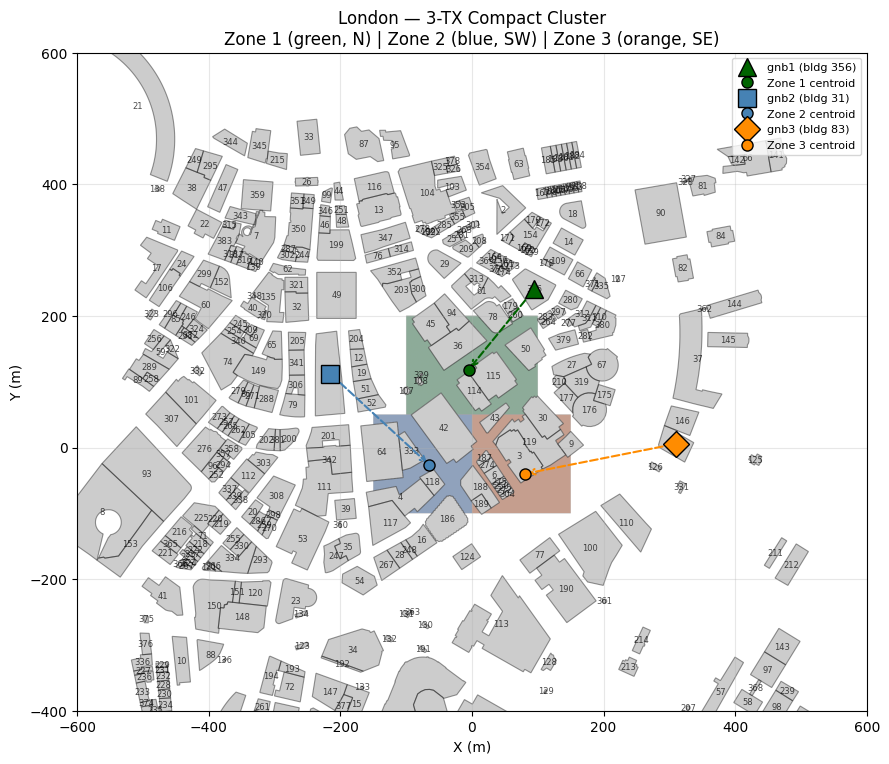

(<Figure size 900x900 with 1 Axes>,
 <Axes: title={'center': 'London — 3-TX Compact Cluster\nZone 1 (green, N) | Zone 2 (blue, SW) | Zone 3 (orange, SE)'}, xlabel='X (m)', ylabel='Y (m)'>)

In [6]:
# ── ZONE VISUALIZATION ───────────────────────────────────────────────────────
zone_entries = [
    dict(mask=zone_mask1, cmap='Greens', color='darkgreen',
         tx_pos=tx1_pos, tx_name=TX1_NAME, building_id=TX1_BUILDING_ID,
         centroid_xy=zone_stats1['centroid_xy'], zone_label='Zone 1 centroid', marker='^'),
    dict(mask=zone_mask2, cmap='Blues', color='steelblue',
         tx_pos=tx2_pos, tx_name=TX2_NAME, building_id=TX2_BUILDING_ID,
         centroid_xy=zone_stats2['centroid_xy'], zone_label='Zone 2 centroid', marker='s'),
    dict(mask=zone_mask3, cmap='Oranges', color='darkorange',
         tx_pos=tx3_pos, tx_name=TX3_NAME, building_id=TX3_BUILDING_ID,
         centroid_xy=zone_stats3['centroid_xy'], zone_label='Zone 3 centroid', marker='D'),
]
plot_zone_overview(
    building_info, MAP_CONFIG, zone_entries,
    title='London \u2014 3-TX Compact Cluster\nZone 1 (green, N) | Zone 2 (blue, SW) | Zone 3 (orange, SE)',
    xlim=(-600, 600), ylim=(-400, 600),
)

In [7]:
# ── CONVERGENCE HELPER ───────────────────────────────────────────────────────
def check_convergence(suite_output, baseline_id, tx_name=None, tol=1e-4):
    """Report convergence status for a baseline.

    Priority:
      1. If the optimizer fired early stopping, report that directly.
      2. Otherwise, inspect the loss history for residual oscillation.
    """
    entry = suite_output["results"].get(baseline_id, {})
    opt   = entry.get("optimizer_result")
    if not isinstance(opt, dict):
        return {"status": "error"}

    joint          = opt.get("joint", {})
    converged_iter = joint.get("converged_iter")
    loss_history   = joint.get("loss_history", [])
    n_iters        = len(loss_history)

    # 1. Early stopping recorded by the optimizer
    if converged_iter is not None:
        return {"status": "converged (early stop)", "iteration": converged_iter,
                "of": n_iters}

    # 2. Single-evaluation baselines (UMa, random search if n_candidates=1, etc.)
    if n_iters <= 1:
        return {"status": "single evaluation"}

    # 3. Ran to max iterations — check how oscillatory the tail was
    window = min(10, n_iters)
    recent = loss_history[-window:]
    deltas = [recent[k + 1] - recent[k] for k in range(len(recent) - 1)]
    if deltas:
        n_flips   = sum(1 for k in range(len(deltas) - 1)
                        if deltas[k] * deltas[k + 1] < 0)
        net_change = abs(recent[-1] - recent[0])
        return {
            "status":     "ran to max iterations",
            "iterations": n_iters,
            "tail_flips": n_flips,
            "tail_net_Δloss": round(net_change, 5),
        }

    return {"status": "ran to max iterations", "iterations": n_iters}

In [ ]:
# ── RUN SUITE ────────────────────────────────────────────────────────────────
tx_configs = [
    TxConfig(name=TX1_NAME, building_id=TX1_BUILDING_ID,
             zone_params=zone_params1, tx_height_offset=TX1_HEIGHT_M, num_sample_points=best_n),
    TxConfig(name=TX2_NAME, building_id=TX2_BUILDING_ID,
             zone_params=zone_params2, tx_height_offset=TX2_HEIGHT_M, num_sample_points=best_n),
    TxConfig(name=TX3_NAME, building_id=TX3_BUILDING_ID,
             zone_params=zone_params3, tx_height_offset=TX3_HEIGHT_M, num_sample_points=best_n),
]
exp_config = ExperimentConfig(
    baselines=BASELINES,
    noise_power=NOISE_POWER,
    num_iterations=NUM_ITERATIONS,
    output_path=OUTPUT_PATH,
    dead_tail_percentile=45.0,
    rs_lds="Uniform",
    rs_seed=42
)
suite_output = run_experiment_suite(
    scene=scene,
    tx_configs=tx_configs,
    map_config=MAP_CONFIG,
    scene_xml_path=SCENE_XML_PATH,
    zone_masks=zone_masks,
    exp_config=exp_config,
)


EXPERIMENT SUITE  —  4 baseline(s)  |  3 TX(s)
Initial angles:
  gnb1: Az=230.7°  El=-13.6°  pos=(94.5, 240.3, 37.5)
  gnb2: Az=315.7°  El=-42.1°  pos=(-215.6, 112.4, 179.0)
  gnb3: Az=187.4°  El=-11.0°  pos=(310.3, 5.6, 47.4)


######################################################################
  BASELINE: grad_full_rejection
######################################################################

MULTI-TX SIR OPTIMIZATION  (3 transmitters)
Pre-created 225 receivers ([75, 75, 75] per zone)
  Iter   1/30  loss=-0.4641  lr=3.50e+00  (0.7s)
  Iter   2/30  loss=-0.5143  lr=3.50e+00  (0.7s)
  Iter   3/30  loss=-0.5293  lr=3.50e+00  (0.6s)
  Iter   4/30  loss=-0.5708  lr=3.50e+00  (0.6s)
  Iter   5/30  loss=-0.5693  lr=3.50e+00  (0.6s)
  Iter   6/30  loss=-0.5693  lr=3.50e+00  (0.6s)
  Iter   7/30  loss=-0.5746  lr=3.50e+00  (0.6s)
  Iter   8/30  loss=-0.5964  lr=3.50e+00  (0.6s)
  Iter   9/30  loss=-0.5907  lr=3.50e+00  (0.7s)
  Iter  10/30  loss=-0.5903  lr=3.50e+00  (0.6s)
  Iter  11/

In [ ]:
# ── CONVERGENCE + RESULTS ─────────────────────────────────────────────────────
print(f"\n{'─'*60}")
print(f"  Convergence Analysis  (tol = {JITTER_MAG:.0e} deg)")
print(f"{'─'*60}")
for bid in BASELINES:
    print(f"  {bid}")
    for tx_name in ALL_TX_NAMES:
        conv = check_convergence(suite_output, bid, tx_name, tol=JITTER_MAG)
        print(f"    {tx_name:<8s}  {conv}")

print("\n")
df = compare_all_results(suite_output, metrics=METRICS)

In [ ]:
# ── VISUALIZATION ─────────────────────────────────────────────────────────────
plot_metric_bars(
    suite_output,
    metrics=("rsrp_mean_dbm", "rsrp_p10_dbm", "sir_median_db", "sir_p10_db"),
)
plt.title(f"RSRP & SINR — All TXs (avg), n={best_n}")
plt.tight_layout(); plt.show()

# Baselines without the random search
BASELINES_WO_RS      = [
    "grad_full_rejection", "grad_full_triangulated", "grad_proportional",
    "pso", "coordinate_descent", "uma_naive"
]

plot_loss_curves(suite_output, baselines=BASELINES_WO_RS, x_axis="wall_time", normalize=True)
plt.title("Convergence Curves")
plt.tight_layout(); plt.show()

plot_cdf(suite_output, metric="rsrp_values_dbm")
plt.title("RSRP CDF")
plt.tight_layout(); plt.show()

In [ ]:
# ── PER-TX BREAKDOWN ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for row_i, tx_name in enumerate(ALL_TX_NAMES):
    for col_i, metric in enumerate(["rsrp_values_dbm", "sir_values_db"]):
        ax = axes[row_i][col_i]
        plot_cdf(suite_output, metric=metric, tx_name=tx_name, ax=ax)
        label = metric.replace('_values_dbm', ' (dBm)').replace('_values_db', ' (dB)')
        ax.set_title(f"{tx_name} — {label}")

plt.suptitle("Per-TX CDF: RSRP and SINR", y=1.01)
plt.tight_layout(); plt.show()